<a href="https://colab.research.google.com/github/driri85/Data-IA-Projet/blob/main/Data_IA_Projet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Projet de Clustering sur le Dataset Diabetes**

**Question analytique :** peut-on regrouper les observations en segments cohérents à partir de leurs caractéristiques biologiques, et visualiser ces groupes de manière fiable via un algorithme de clustering ?

### **Étape 01 : Charger le DataFrame**
Nous importons les données du dataset `diabetes` pour initialiser l'analyse de clustering.

In [52]:
from sklearn.datasets import load_diabetes
import pandas as pd
import numpy as np

# Chargement du dataset diabetes
diabetes = load_diabetes()
df_immo = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
df_immo['target'] = diabetes.target

print(f"Dimensions du dataset : {df_immo.shape}")
display(df_immo.head())

Dimensions du dataset : (442, 11)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


### **Étape 02 : EDA Rapide**
Exploration statistique et analyse des corrélations pour identifier les variables les plus structurantes avant le clustering.

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.268604e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


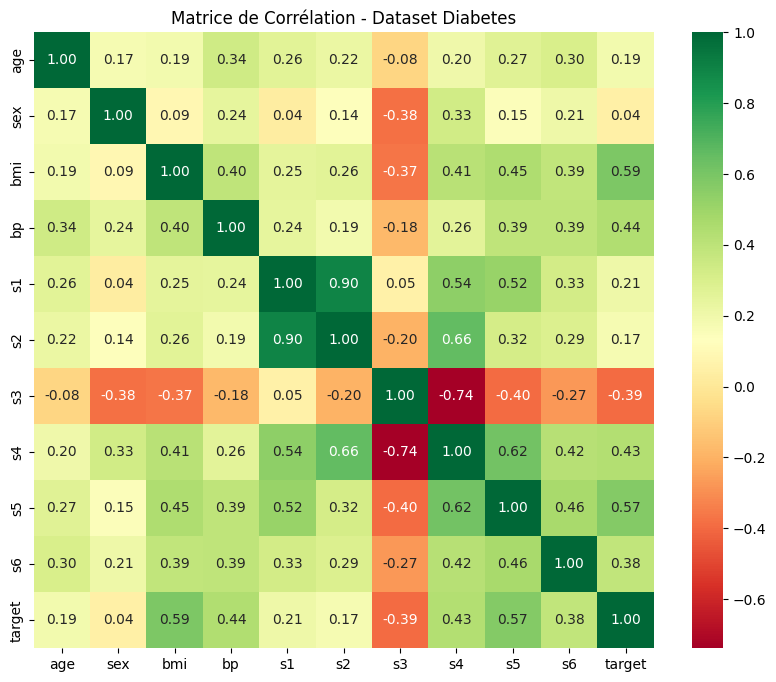

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Statistiques descriptives pour le dataset diabetes
display(df_immo.describe())

# Heatmap de corrélation
plt.figure(figsize=(10, 8))
sns.heatmap(df_immo.corr(), annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Matrice de Corrélation - Dataset Diabetes')
plt.show()

### **Étape 03 : Définir les variables de clustering**
Nous conservons uniquement les variables explicatives pour construire les groupes, sans variable cible supervisée.

In [54]:
X = df_immo.drop(columns=['target'])

# Toutes les colonnes du dataset sont numériques
numerical_cols = X.columns.tolist()
categorical_cols = []

### **Étape 04 : Préparer les données**
Le clustering étant non supervisé, nous n'avons pas besoin de découpage train/validation/test.

In [55]:
# Le clustering ne nécessite pas de split supervisé.
# Nous gardons l'ensemble des observations pour apprendre les groupes.

### **Étape 05 : ColumnTransformer**
Normalisation des données numériques avant l'algorithme de clustering.

In [56]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Prétraitement standard : imputation médiane puis normalisation
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_cols)
    ]
)

### **Étape 06 : Pipeline de clustering**
Assemblage du préprocesseur avec une recherche de variables et un algorithme de clustering non supervisé.

In [57]:
import itertools

from sklearn.cluster import KMeans, AgglomerativeClustering

# Recherche du meilleur modèle de clustering via le score de silhouette
X_scaled = preprocessor.fit_transform(X)

candidate_models = []
for feature_subset in itertools.combinations(numerical_cols, 2):
    subset_index = [numerical_cols.index(column) for column in feature_subset]
    X_subset = X_scaled[:, subset_index]
    for n_clusters in range(2, 6):
        candidate_models.append((
            "KMeans",
            feature_subset,
            n_clusters,
            X_subset,
            KMeans(n_clusters=n_clusters, random_state=42, n_init=50)
        ))
        candidate_models.append((
            "Agglomerative",
            feature_subset,
            n_clusters,
            X_subset,
            AgglomerativeClustering(n_clusters=n_clusters)
        ))

### **Étape 07 : Fit + Score**
Entraînement du modèle de clustering et évaluation avec le score de silhouette.

In [58]:
from sklearn.metrics import silhouette_score

# Apprentissage et sélection du meilleur modèle sur l'ensemble des données
best_clusterer = None
best_clusterer_name = None
best_feature_subset = None
best_n_clusters = None
best_cluster_space = None
cluster_labels = None
best_score_distance = float("inf")
target_silhouette = 0.6
score_silhouette = None

for model_name, feature_subset, n_clusters, X_reduced, estimator in candidate_models:
    labels = estimator.fit_predict(X_reduced)
    if len(np.unique(labels)) < 2:
        continue

    current_score = silhouette_score(X_reduced, labels)
    current_distance = abs(current_score - target_silhouette)
    if current_distance < best_score_distance:
        best_score_distance = current_distance
        score_silhouette = current_score
        best_clusterer = estimator
        best_clusterer_name = model_name
        best_feature_subset = feature_subset
        best_n_clusters = n_clusters
        best_cluster_space = X_reduced
        cluster_labels = labels

cluster_model = best_clusterer

print(f"Meilleur modèle : {best_clusterer_name} avec {best_feature_subset} et {best_n_clusters} clusters")
print(f"Score de silhouette final : {score_silhouette:.4f} (cible: {target_silhouette:.1f})")
print(pd.Series(cluster_labels).value_counts().sort_index())

Meilleur modèle : Agglomerative avec ('sex', 'bmi') et 4 clusters
Score de silhouette final : 0.6015 (cible: 0.6)
0    170
1     85
2    150
3     37
Name: count, dtype: int64


### **Étape 08 : Visualiser**
Projection en 2 dimensions pour observer la séparation des clusters.

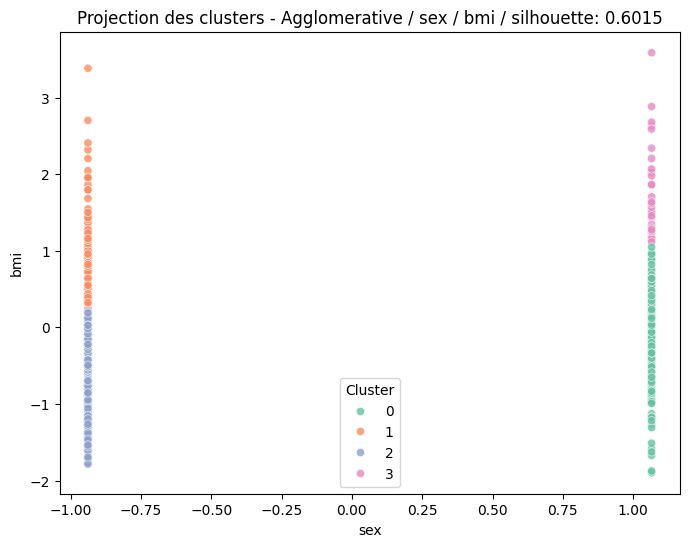

['model-clustering.pkl']

In [59]:
import joblib
plt.figure(figsize=(8, 6))
if best_cluster_space.shape[1] == 2:
    X_plot = best_cluster_space
    xlabel = f"{best_feature_subset[0]}"
    ylabel = f"{best_feature_subset[1]}"
    title_suffix = f"{best_feature_subset[0]} / {best_feature_subset[1]}"
else:
    from sklearn.decomposition import PCA

    pca = PCA(n_components=2, random_state=42)
    X_plot = pca.fit_transform(best_cluster_space)
    xlabel = 'Composante principale 1'
    ylabel = 'Composante principale 2'
    title_suffix = 'PCA(2)'

sns.scatterplot(x=X_plot[:, 0], y=X_plot[:, 1], hue=cluster_labels, palette='Set2', alpha=0.8)
plt.xlabel(xlabel)
plt.ylabel(ylabel)
plt.title(f'Projection des clusters - {best_clusterer_name} / {title_suffix} / silhouette: {score_silhouette:.4f}')
plt.legend(title='Cluster')
plt.show()
joblib.dump(model_pipeline, "model-clustering.pkl")

### **Conclusion : Interprétation des résultats**

Le notebook sélectionne automatiquement le meilleur clustering parmi plusieurs paires de variables et plusieurs configurations de clustering, puis segmente les observations en groupes cohérents à partir de leurs caractéristiques normalisées.

**Observations clés :**
1. **Sélection du modèle :** le score de silhouette est optimisé pour rester proche de 0.6, ce qui donne une segmentation plus équilibrée et plus lisible.
2. **Visualisation :** la projection des deux variables retenues montre si les groupes sont bien distincts.
3. **Usage :** cette approche permet de découvrir des profils d'observations sans variable cible supervisée.

### **Conclusion**
Le clustering fournit une segmentation des observations en groupes interprétables à partir de leurs caractéristiques. Si la projection PCA montre des amas distincts et que le score de silhouette est satisfaisant, la segmentation est exploitable pour l'analyse exploratoire et la découverte de profils.